In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from os.path import join as pjoin
import csv
from scipy.optimize import minimize
import re

import processing_fun
importlib.reload(processing_fun)

from utils import OperonArgs

# Distribution of Parameters

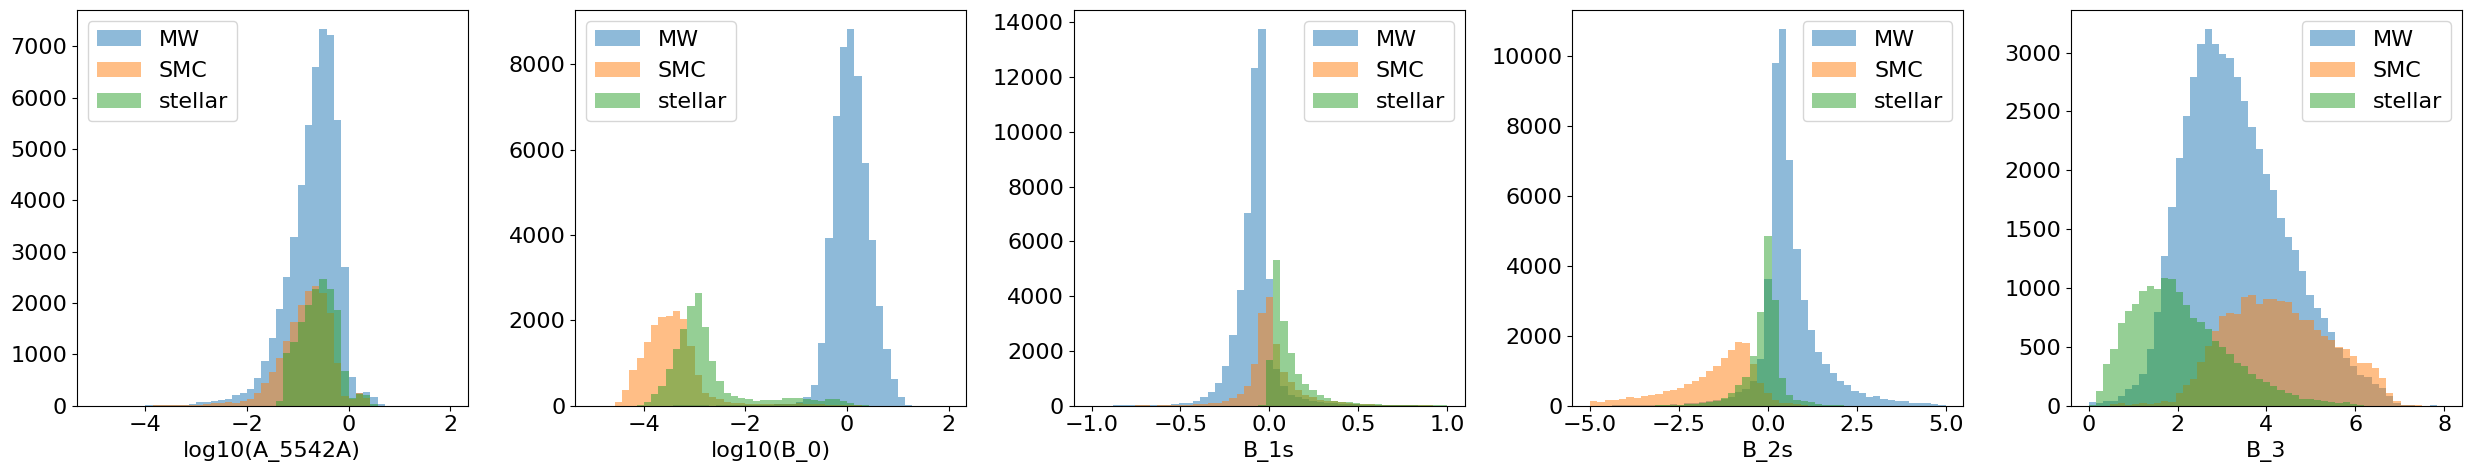

In [63]:
fname = 'fits/B_0_13/B_0_train_10.csv'
ytrue, ypred = np.loadtxt(fname, usecols=(-2, -1), unpack=True)
# plt.hist(np.log10(ytrue), bins=50);

bins = np.linspace(-5, 2, 50)

keep_cols = ['A_5542A', 'B_0', 'B_1s', 'B_2s', 'B_3']
do_log = [True, True, False, False, False]
all_bins = [np.linspace(-5, 2, 50), np.linspace(-5, 2, 50), np.linspace(-1, 1, 50), np.linspace(-5, 5, 50), np.linspace(0, 8, 50)]

fig, axs = plt.subplots(1, len(keep_cols), figsize=(5*len(keep_cols), 5))

for dust_mixture in ['MW', 'SMC', 'stellar']:
    if dust_mixture == 'MW':
        fname = f'/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust_mixture}_los09.dat'
    else:
        fname = f'/mnt/users/deaglan/symbolic_regression/iob-attenuation/data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust_mixture}_all.dat'

    out_lines = []
    with open(fname, "r") as fh:
        header = next(fh)
        # Remove any part of header between square brackets, as this is not a valid column name and causes problems for pandas
        header = re.sub(r'\[.*?\]', '', header)
    header = header.strip().split()
    # Only load column B0
    df = pd.read_csv(fname, sep=r'\s+', names=header, comment='#', low_memory=False, skiprows=1, usecols=keep_cols)

    for ax, col, log, bins in zip(axs, keep_cols, do_log, all_bins):
        values = df[col].values
        values = values[np.isfinite(values)]
        if log:
            values = values[values > 0]
            values = np.log10(values)
        ax.hist(values, bins=bins, alpha=0.5, label=dust_mixture, histtype='stepfilled')
        if log:
            ax.set_xlabel(f'log10({col})')
        else:
            ax.set_xlabel(col)
        ax.legend()
fig.tight_layout()

# Av

Searching for a function of galaxy properties which is agnostic to dust mixture

Test if Av is exact or inferred

In [ ]:
fname = '../data/merged_bestfit_galprops_SMC.dat'
df_fit = pd.read_csv(fname, sep=r'\s+', usecols=["#galaxy_id", "los", "Av"])
df_fit.rename(columns={'#galaxy_id': 'galaxy_id'}, inplace=True)

fname = '../data/gal_los_iobcomp_attcurve_galprop_29_01_SMC.dat'
df_data = pd.read_csv(fname, sep=r'\s+', usecols=["galaxy_id", "los", "A_5542A"])

# Merge the two dataframes on galaxy_id and los
df_merged = pd.merge(df_fit, df_data, on=['galaxy_id', 'los'])

# See if the two equal
print(np.all(df_merged['Av'] == df_merged['A_5542A']))

Operon fits


Reading from configuration file: conf/Av_4.ini
Reading from selection file: conf/selection_11.ini

All model lengths:
[ 5  6  7  8  9 11 13 14 15 16 17 19 21 23 24]

Equation requested:
(0.252021 + (1.409410 * (((0.897000 * X11) ^ ((0.000108 * X10) ^ (-0.215031))) - ((941.292236 * X9) ^ ((-4.488379) * X5)))))


100%|██████████| 15/15 [00:05<00:00,  2.76it/s]



Latex version:
b_{0} \left(b_{1} \sin{\left(i \right)}\right)^{b_{2} sSFR^{- b_{3}}} + b_{4} - b_{5} \left(\Sigma_{SFR} b_{6}\right)^{- Z_{gas} b_{7}}

Number of parameters: 8
Values: [1.40941, 0.897, 7.12749393510718, 0.215031, 0.252021, 1.40941, 941.292236, 4.488379]

1 - R2 for chosen model:
Training: 0.3872
Validation: 0.3766

R2 for chosen model:
Training: 0.6128
Validation: 0.6234

Reading from configuration file: conf/Av_4.ini
Reading from selection file: conf/selection_11.ini


(<Figure size 1200x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'log10(Av): Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'log10(Av): Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

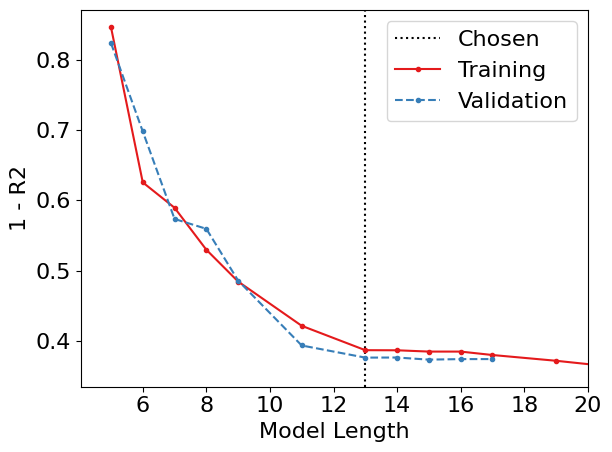

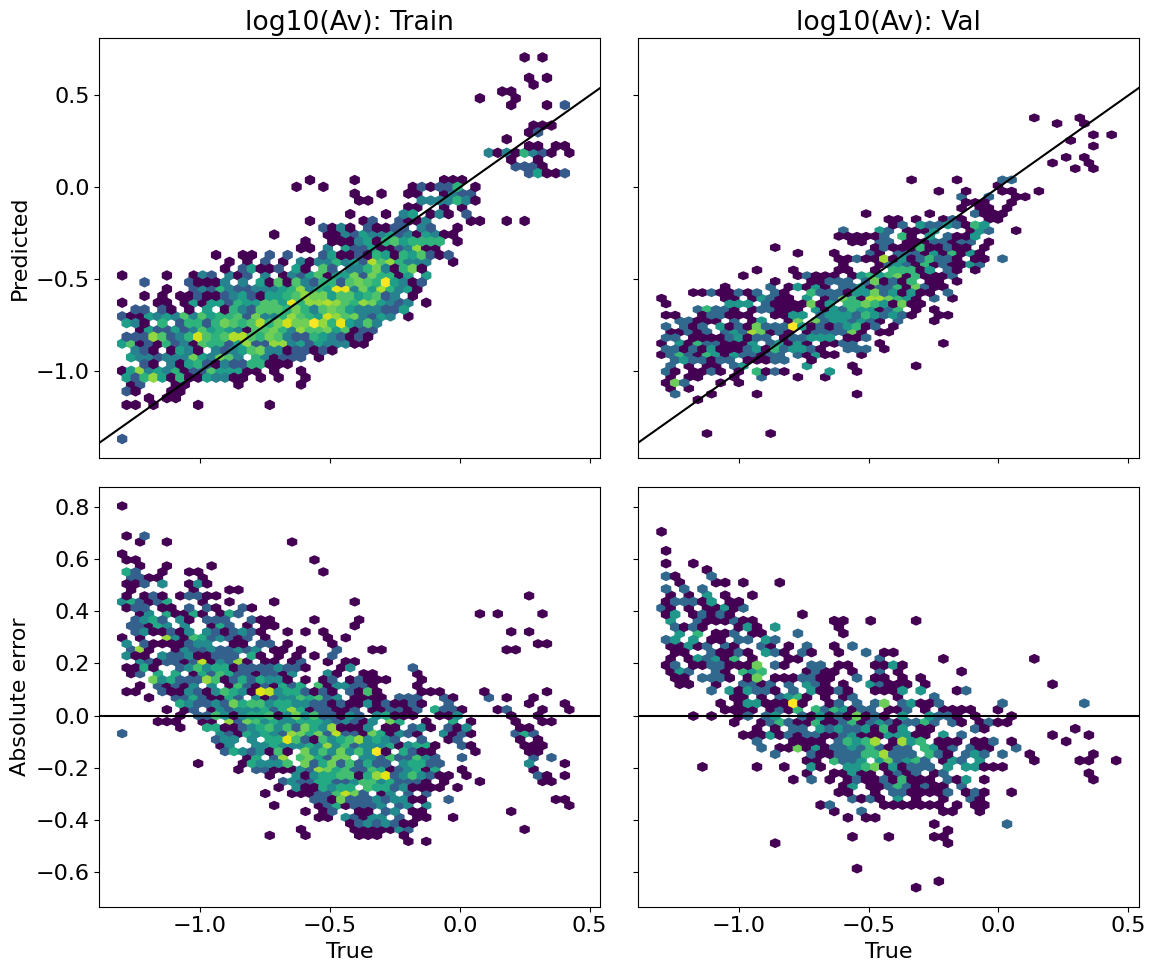

In [ ]:
# --------------------------------------------------------
# These models include SFR_compact as a feature

ini_file = 'conf/Av_0.ini'; ilen = 17
ini_file = 'conf/Av_1.ini'; ilen = 13
ini_file = 'conf/Av_2.ini'; ilen = 14
ini_file = 'conf/Av_3.ini'; ilen = 11

# --------------------------------------------------------
# These models do not include SFR_compact as a feature

ini_file = 'conf/Av_4.ini'; ilen = 13
# ini_file = 'conf/Av_5.ini'; ilen = 12

# --------------------------------------------------------
# These models do not include SFR_compact as a feature
# and depend on dust mixture parameters

# ini_file = 'conf/Av_6.ini'; ilen = None
# ini_file = 'conf/Av_7.ini'; ilen = None

# Av_4; ilen=13
# Training: 0.6128
# Validation: 0.6234

# CAVEAT: Validation contains some bad LOS for MW dust

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

# $B_0$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust

In [ ]:
ini_file = 'conf/B0_0.ini'; ilen = None
ini_file = 'conf/B0_3.ini'; ilen = None

# These runs don't depend on B2
ini_file = 'conf/B0_6.ini'; ilen = None
ini_file = 'conf/B0_9.ini'; ilen = None

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
# processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

## SMC dust

In [ ]:
ini_file = 'conf/B0_1.ini'; ilen = None
ini_file = 'conf/B0_4.ini'; ilen = None

# These runs don't depend on B2
ini_file = 'conf/B0_7.ini'; ilen = None
# ini_file = 'conf/B0_10.ini'; ilen = None

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
# processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

## Stellar dust

In [ ]:
ini_file = 'conf/B0_2.ini'; ilen = 16
ini_file = 'conf/B0_5.ini'; ilen = 14

# These runs don't depend on B2
ini_file = 'conf/B0_8.ini'; ilen = 18
ini_file = 'conf/B0_11.ini'; ilen = 16

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
# processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

## Mixed dust

In [ ]:
# These runs don't depend on B2
ini_file = 'conf/B0_12.ini'; ilen = 10
ini_file = 'conf/B0_13.ini'; ilen = 10

# These runs do depend on B2
# ini_file = 'conf/B0_14.ini'; ilen = 10
# ini_file = 'conf/B0_15.ini'; ilen = 10

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False, log_target=True)

# $B_1$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B1_3.ini
Reading from selection file: conf/selection_12.ini

All model lengths:
[ 5  6  7  9 11 13 14 16 18 19 20 21 22 23 24]

Equation requested:
((-1.256498) + (1.135782 * ((0.252926 * X11) ^ ((-1.953790) * X5))))


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 106.41it/s]


Latex version:
- b_{0} + b_{1} \left(A_{V} b_{2}\right)^{- Z_{gas} b_{3}}

Number of parameters: 4
Values: [1.256498, 1.135782, 0.252926, 1.95379]

1 - R2 for chosen model:
Training: 0.7742
Validation: 0.8126

R2 for chosen model:
Training: 0.2258
Validation: 0.1874

Reading from configuration file: conf/B1_3.ini
Reading from selection file: conf/selection_12.ini


(<Figure size 1200x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'B_1s: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_1s: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

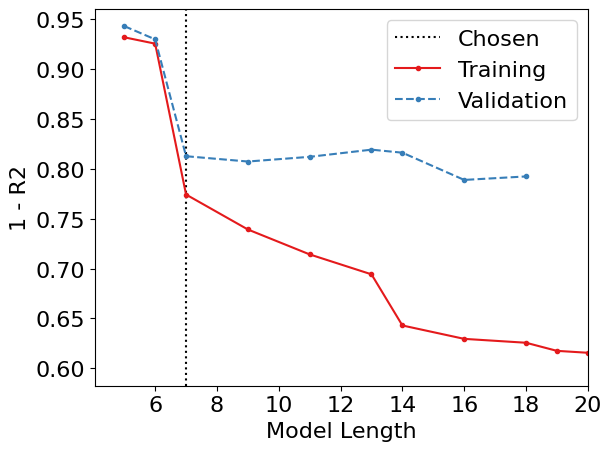

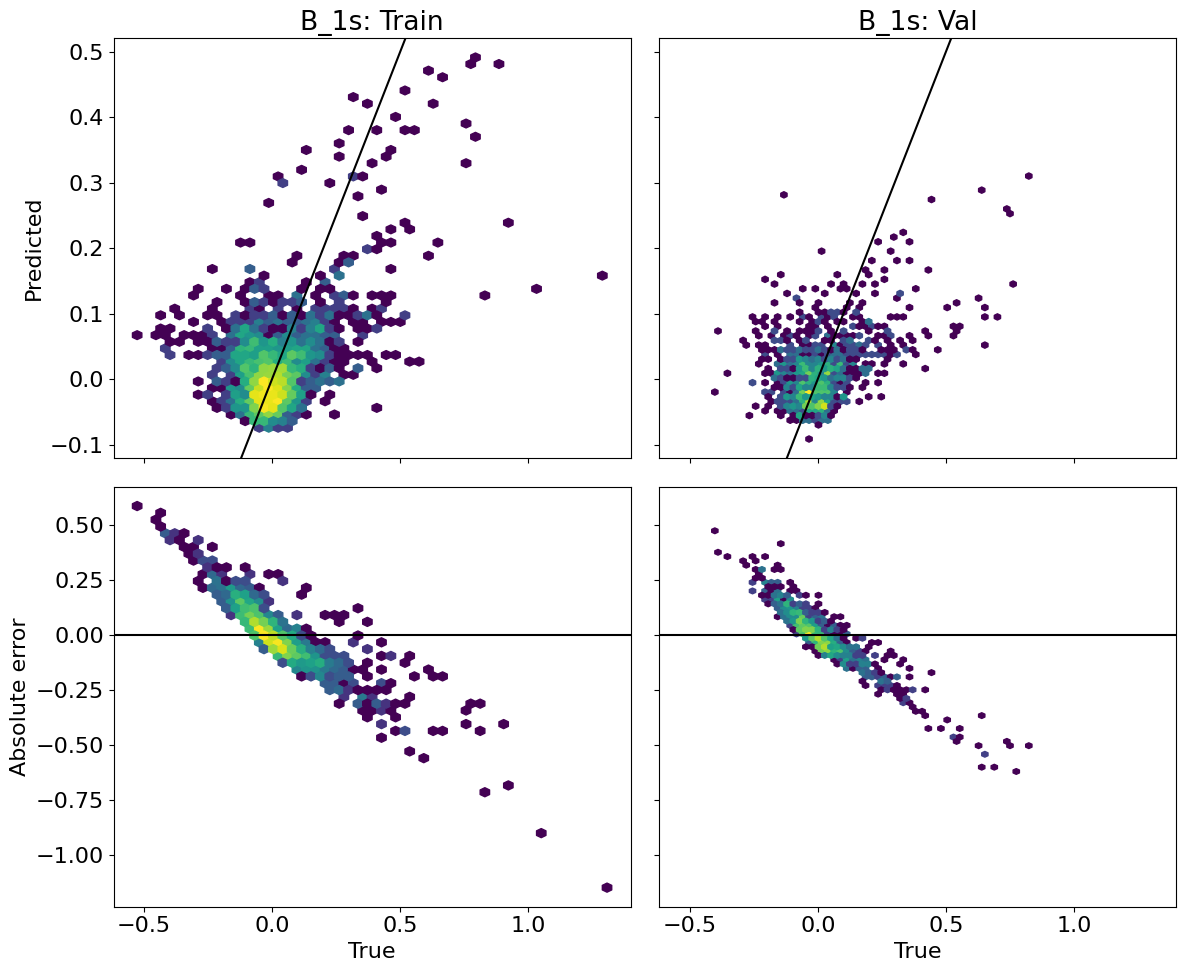

In [ ]:
# --------------------------------------------------------
# These models include SFR_compact as a feature

ini_file = 'conf/B1_0.ini'; ilen = 14
ini_file = 'conf/B1_1.ini'; ilen = 15
ini_file = 'conf/B1_2.ini'; ilen = 15

# --------------------------------------------------------
# These models do not include SFR_compact as a feature

ini_file = 'conf/B1_3.ini'; ilen = 7
# ini_file = 'conf/B1_4.ini'; ilen = 7

# --------------------------------------------------------
# These models do not include SFR_compact as a feature
# and depend on dust mixture parameters

# ini_file = 'conf/B1_5.ini'; ilen = None
# ini_file = 'conf/B1_6.ini'; ilen = None

processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)

# $B_2$

Searching for a function of other fit parameters specific to a given dust mixture

## MW dust


Reading from configuration file: conf/B2_9.ini
Reading from selection file: conf/selection_5.ini

All model lengths:
[ 5  7  9 10 11 12 13 15 17 19 21 22 23 24]

Equation requested:
((-0.071765) + (1.022905 * ((((1.442695 * X3) ^ ((-0.148324) * X2)) + ((-12.092427) * X1)) / ((0.424835 * X2) + ((0.170208 * X2) ^ (22.520847 * X1))))))


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 101.31it/s]


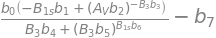


Latex version:
\frac{b_{0} \left(- B_{1s} b_{1} + \left(A_{V} b_{2}\right)^{- B_{3} b_{3}}\right)}{B_{3} b_{4} + \left(B_{3} b_{5}\right)^{B_{1s} b_{6}}} - b_{7}

Number of parameters: 8
Values: [1.022905, 12.092427, 1.442695, 0.148324, 0.424835, 0.170208, 22.520847, 0.071765]

1 - R2 for chosen model:
Training: 0.5846
Validation: 0.6142

R2 for chosen model:
Training: 0.4154
Validation: 0.3858


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

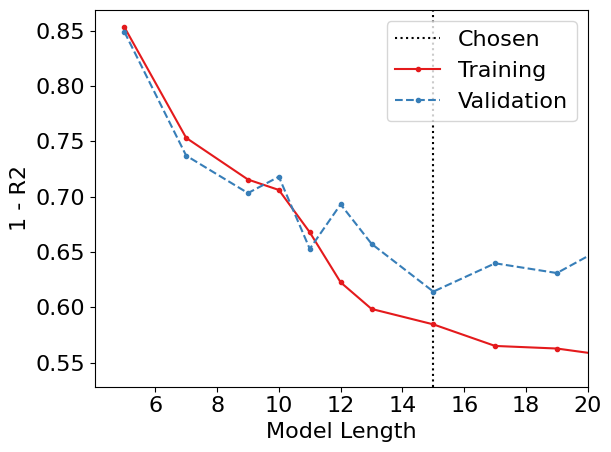

In [16]:
ini_file = 'conf/B2_0.ini'; ilen = 15
ini_file = 'conf/B2_3.ini'; ilen = 15

# These runs don't depend on B0
ini_file = 'conf/B2_6.ini'; ilen = 15
ini_file = 'conf/B2_9.ini'; ilen = 15

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## SMC dust


Reading from configuration file: conf/B2_10.ini
Reading from selection file: conf/selection_6.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 19 21 23]

Equation requested:
((-0.398182) + ((-3.260219) * ((0.114272 * X2) ^ log((35.698448 * X3)))))


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:00<00:00, 106.65it/s]



Latex version:
- b_{0} \left(B_{3} b_{1}\right)^{\log{\left(A_{V} b_{2} \right)}} - b_{3}

Number of parameters: 4
Values: [3.260219, 0.114272, 35.698448, 0.398182]

1 - R2 for chosen model:
Training: 0.5440
Validation: 0.8130

R2 for chosen model:
Training: 0.4560
Validation: 0.1870


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

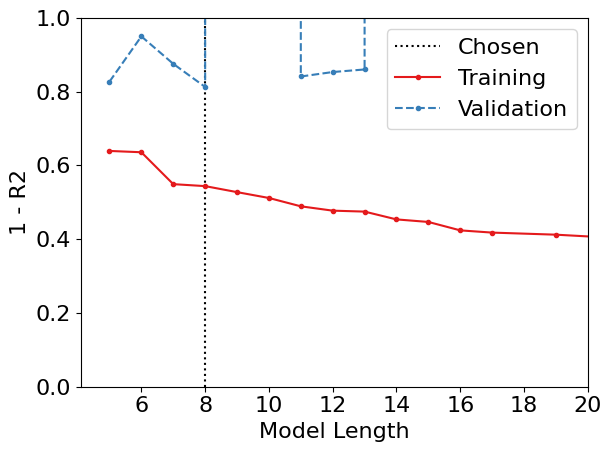

In [18]:
ini_file = 'conf/B2_1.ini'; ilen = 8
ini_file = 'conf/B2_4.ini'; ilen = 8

# These runs don't depend on B0
ini_file = 'conf/B2_7.ini'; ilen = 13
ini_file = 'conf/B2_10.ini'; ilen = 8

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## Stellar dust


Reading from configuration file: conf/B2_11.ini
Reading from selection file: conf/selection_7.ini

All model lengths:
[ 5  7  9 11 13 15 17 18 20 21 23 24]

Equation requested:
(0.128833 + (17853.462891 * (((-0.000012) * X1) / (((((-1.503276) * X1) - ((-0.360355) * X2)) ^ (62.375168 * X1)) - ((-0.019845) * X2)))))


100%|██████████| 12/12 [00:00<00:00, 143.07it/s]


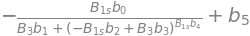


Latex version:
- \frac{B_{1s} b_{0}}{B_{3} b_{1} + \left(- B_{1s} b_{2} + B_{3} b_{3}\right)^{B_{1s} b_{4}}} + b_{5}

Number of parameters: 6
Values: [0.214241554692, 0.019845, 1.503276, 0.360355, 62.375168, 0.128833]

1 - R2 for chosen model:
Training: 0.6094
Validation: 0.6055

R2 for chosen model:
Training: 0.3906
Validation: 0.3945


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='1 - R2'>)

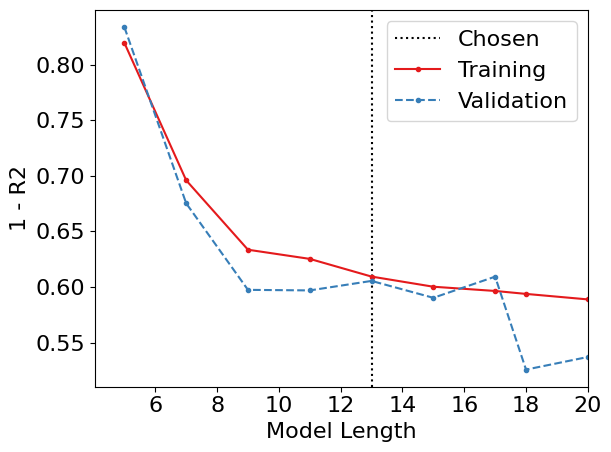

In [23]:
ini_file = 'conf/B2_2.ini'; ilen = 18
ini_file = 'conf/B2_5.ini'; ilen = 15

# These runs don't depend on B0
ini_file = 'conf/B2_8.ini'; ilen = 9
ini_file = 'conf/B2_11.ini'; ilen = 13

importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)

## Mixed dust

In [ ]:
# These runs don't depend on B0
ini_file = 'conf/B2_12.ini'; ilen = None
# ini_file = 'conf/B2_13.ini'; ilen = None

# These runs do depend on B0
ini_file = 'conf/B2_14.ini'; ilen = None
# ini_file = 'conf/B2_15.ini'; ilen = None

# $B_3$

Searching for a function of galaxy properties and $A_{\rm V}$ which is agnostic to dust mixture


Reading from configuration file: conf/B3_3.ini
Reading from selection file: conf/selection_12.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Equation requested:
((-38.723164) + (38.589443 * ((((-147.577759) * X5) / ((-0.575176) * X11)) ^ 0.025685)))


100%|██████████| 19/19 [00:00<00:00, 97.45it/s]



Latex version:
b_{0} \left(\frac{Z_{gas}}{A_{V}}\right)^{b_{1}} - b_{2}

Number of parameters: 3
Values: [44.4989055546875, 0.025685, 38.723164]

1 - R2 for chosen model:
Training: 0.6248
Validation: 0.5872

R2 for chosen model:
Training: 0.3752
Validation: 0.4128

Reading from configuration file: conf/B3_3.ini
Reading from selection file: conf/selection_12.ini


(<Figure size 1200x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'B_3: Train'}, ylabel='Predicted'>,
         <Axes: title={'center': 'B_3: Val'}>],
        [<Axes: xlabel='True', ylabel='Absolute error'>,
         <Axes: xlabel='True'>]], dtype=object))

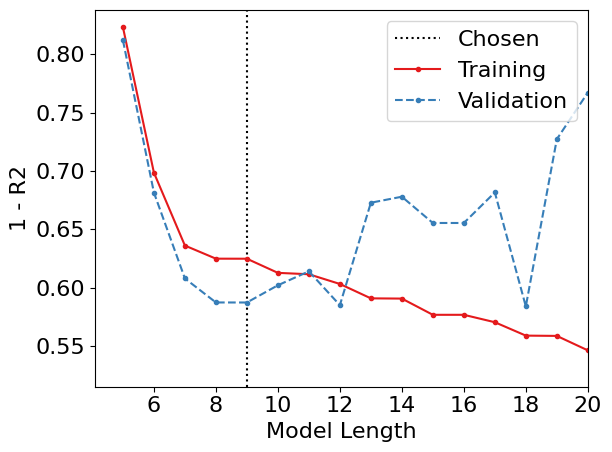

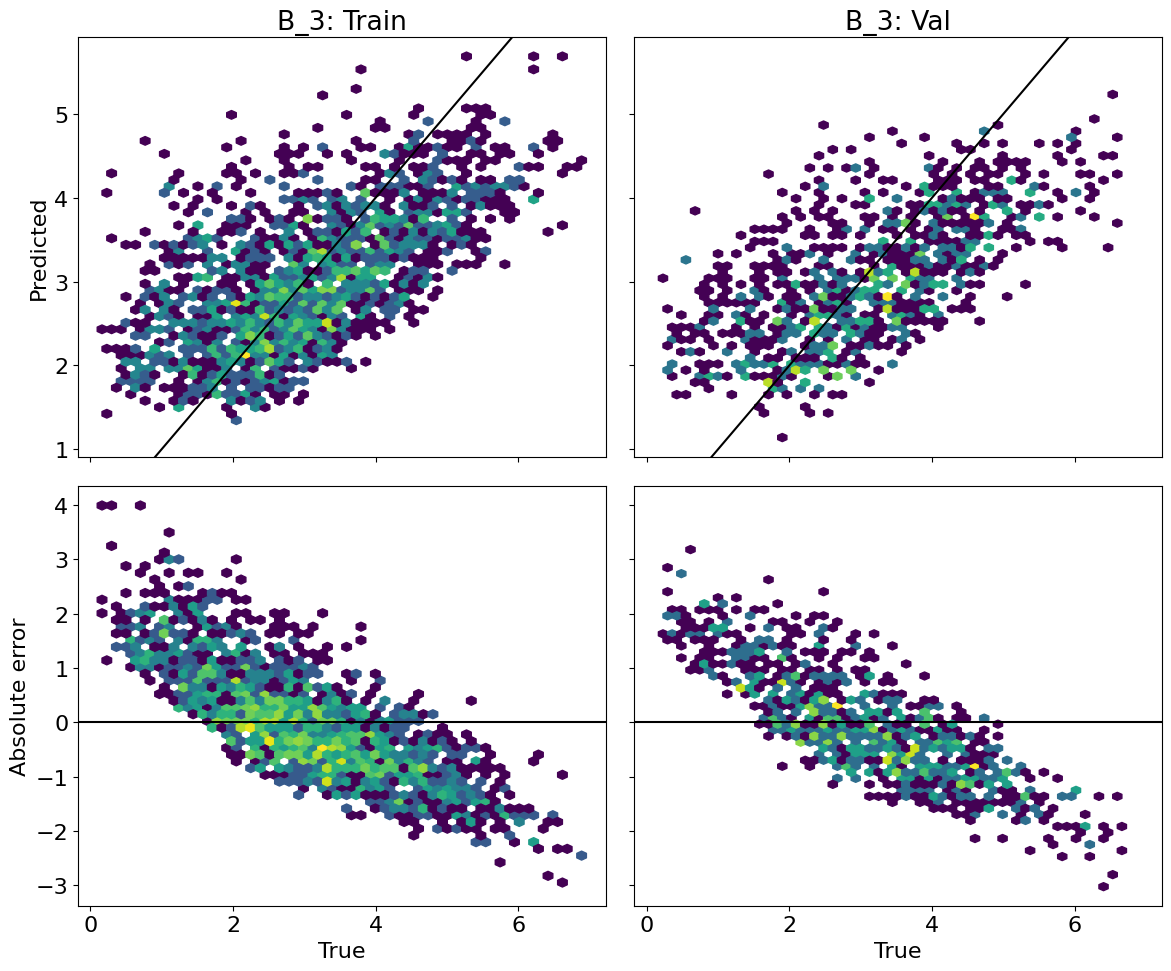

In [ ]:
# --------------------------------------------------------
# These models include SFR_compact as a feature

ini_file = 'conf/B3_0.ini'; ilen = 13
ini_file = 'conf/B3_1.ini'; ilen = 14
ini_file = 'conf/B3_2.ini'; ilen = 11

# --------------------------------------------------------
# These models do not include SFR_compact as a feature

ini_file = 'conf/B3_3.ini'; ilen = 9 # 12
# ini_file = 'conf/B3_4.ini'; ilen = 13
# ini_file = 'conf/B3_5.ini'; ilen = 13

# Currently B3_3 with ilen = 9, 10, or 11 seem ok

# --------------------------------------------------------
# These models do not include SFR_compact as a feature
# and depend on dust mixture parameters

# ini_file = 'conf/B3_6.ini'; ilen = None
# ini_file = 'conf/B3_7.ini'; ilen = None


processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2', yscale='linear', loss_max=1.0)
processing_fun.prediction_plots(ini_file, ilen=ilen, frac_error=False)


Reading from configuration file: conf/B3_3.ini
Reading from selection file: conf/selection_12.ini
fits/B_3_3/B_3_train_12.csv
[15.55910518  2.38024208  1.11047214  0.92599199  0.792312  ]
-0.39686875016596557
[15.5660584   2.38042869  1.11033842  0.9257735   0.79134664]
-0.3968687701949071


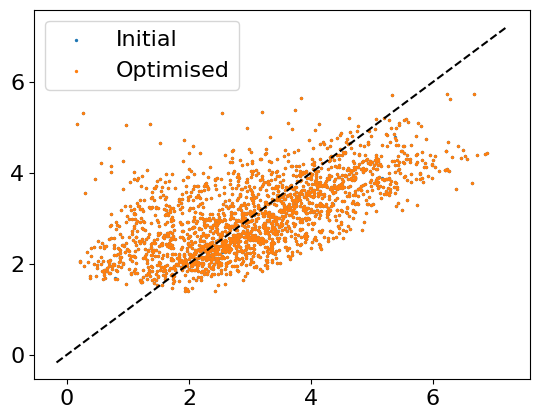

In [ ]:
b = [15.559105180754, 1.033726, 0.00346297105137314, 267.398132, 320.670349, 0.792312]
c = [None] * 5
c[0] = b[0]
c[1] = b[1] * np.log(10)
c[2] = b[2] * b[4]
c[3] = b[2] * b[3]
c[4] = b[5]
c = np.array(c).astype(float)

ini_file = 'conf/B3_3.ini'
length = 12
args = OperonArgs(ini_file)
run_name = f'{args.target_name}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = pjoin(out_dir, f'{args.target_name}_train_{length}.csv')
print(fname)
with open(f'{out_dir}/{run_name}_names.txt', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    names = reader.__next__()
names[-1] = 'true'
names.append('pred')
df = pd.read_csv(fname, names=names, sep=r'\s+')

def my_pred(c):
    return c[0] * df['Zgas'] + c[1] * np.log10((c[2] * df['logMstar'] - c[3] * df['logMgas']) / df['Av']) + c[4]

def my_loss(c):
    pred = my_pred(c)
    R2 = 1 - np.sum((pred - df['true'])**2) / np.sum((df['true'] - np.mean(df['true']))**2)
    return -R2

print(c)
print(my_loss(c))
res = minimize(my_loss, c, method='Nelder-Mead')
print(res.x)
print(my_loss(res.x))

# pred = b[0] * df['Zgas'] + b[1] * np.log(b[2] * (-b[3] * df['logMgas'] + b[4] * df['logMstar']) / df['Av']) + b[5]

plt.scatter(df['true'], my_pred(c), s=2, label='Initial')
plt.scatter(df['true'], my_pred(res.x), s=2, label='Optimised')
plt.legend()
xlim = plt.xlim()
plt.plot(xlim, xlim, 'k--')